In [1]:
import cafe

output_dir = "./output/26.03.19-case_gastrulation_local_visualization"
img_dir = "./img/26.03.19-case_gastrulation_local_visualization"

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

In [2]:
model_name = "merge"

# read raw fadata
filename = "output/26.02.02-gastrulation_case_data/gastrulation.h5ad"
fadata = cafe.data.read_h5ad(filename)
fadata

AnnData object with n_obs × n_vars = 89267 × 53801
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom', 'celltype_coarse', 'celltype_new', 'pseudotime'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'cafe', 'celltype_coarse_colors', 'celltype_colors', 'celltype_new_colors', 'id'
    obsm: 'X_pca', 'X_stavia', 'X_umap'
    layers: 'spliced', 'unspliced'

INFO     |- Processed milestone: Blast, fadata_sub shape: (23186, 53801), model_name: `ref`                                                                                                             
INFO     |- Processed milestone: Ectoderm, fadata_sub shape: (9044, 53801), model_name: `ref`                                                                                                           
INFO     |- Processed milestone: Mesoderm, fadata_sub shape: (22245, 53801), model_name: `ref`                                                                                                          
INFO     |- Processed milestone: Endoderm, fadata_sub shape: (4004, 53801), model_name: `ref`                                                                                                           
ERROR    |- Error occurred while plotting for milestone: Neural, Error: 'path' is not a valid quadratic Bezier curve                                                                                

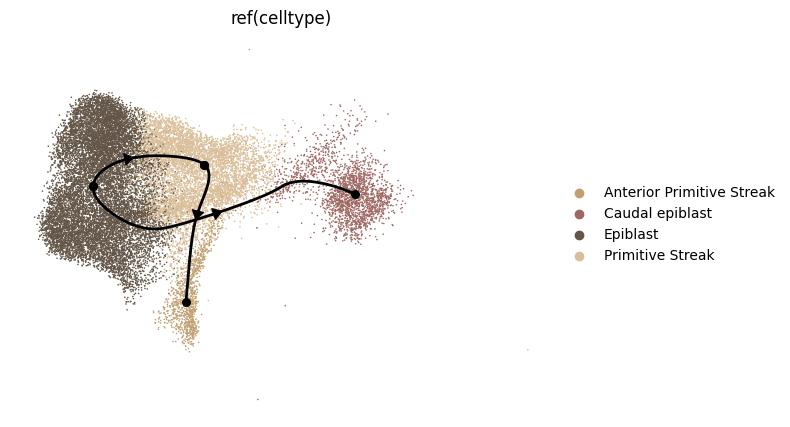

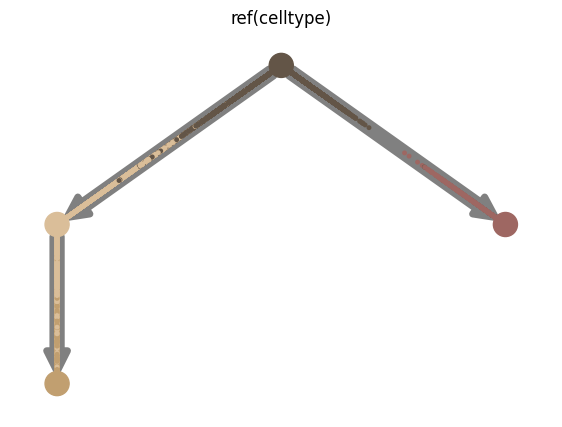

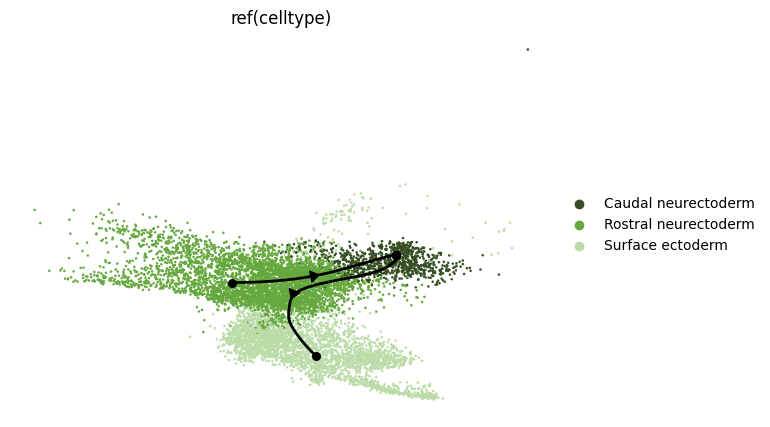

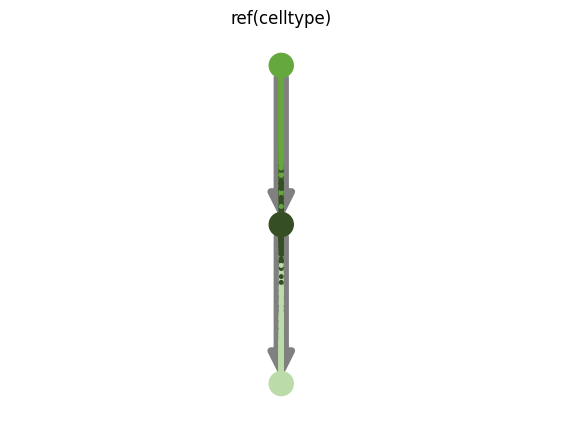

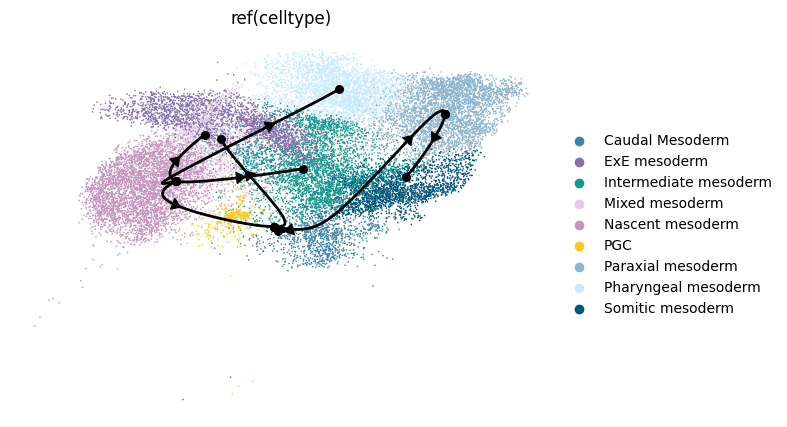

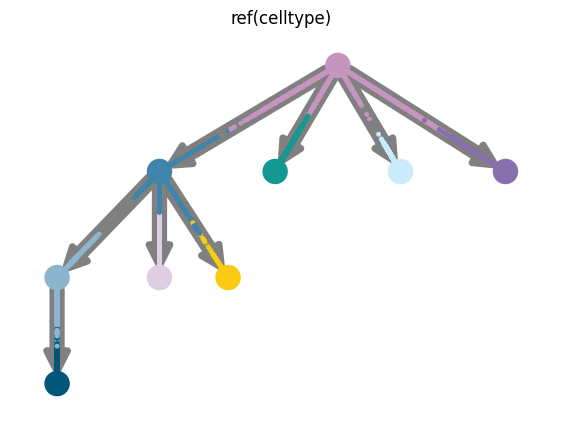

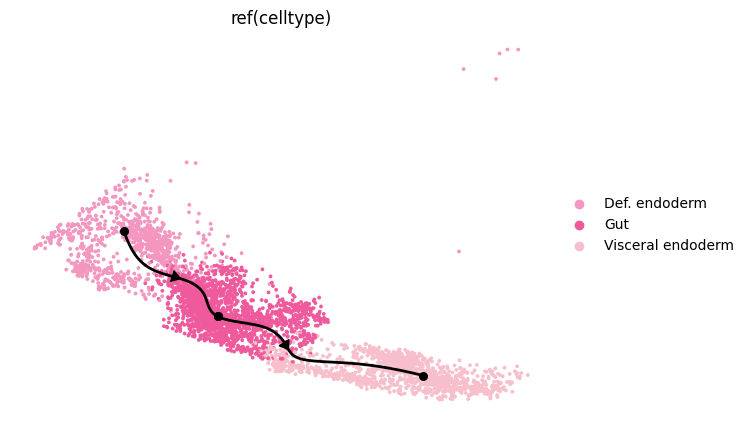

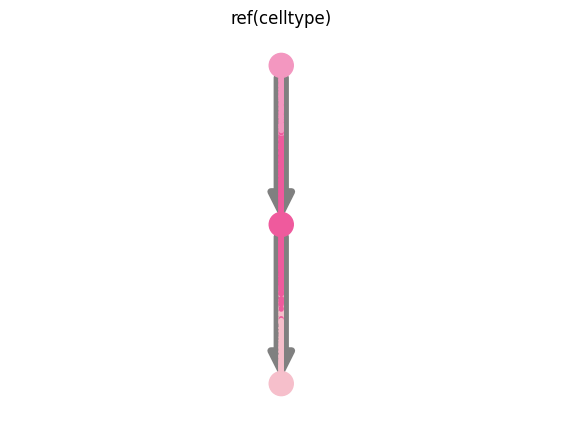

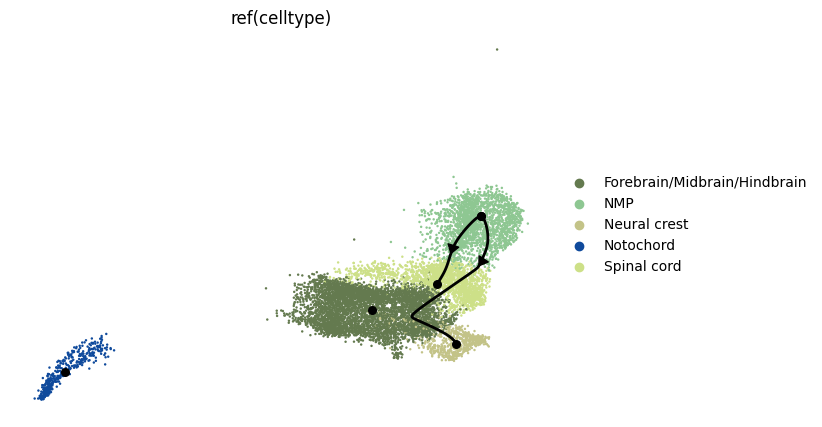

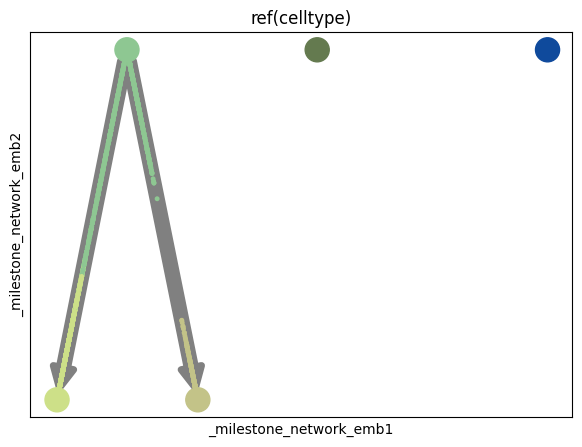

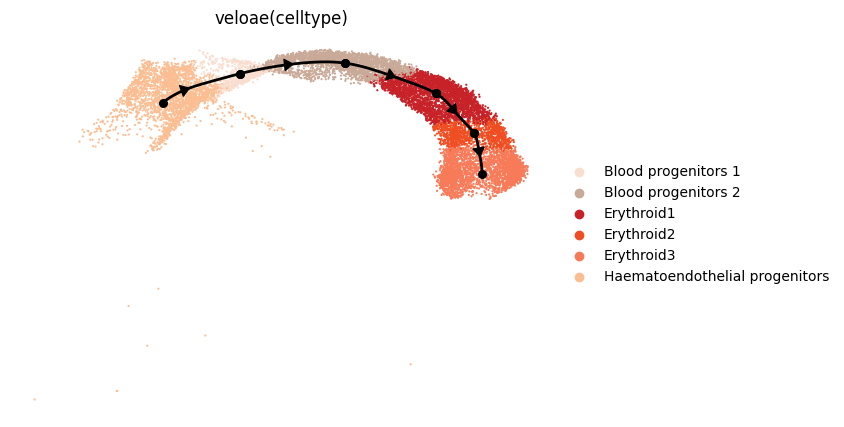

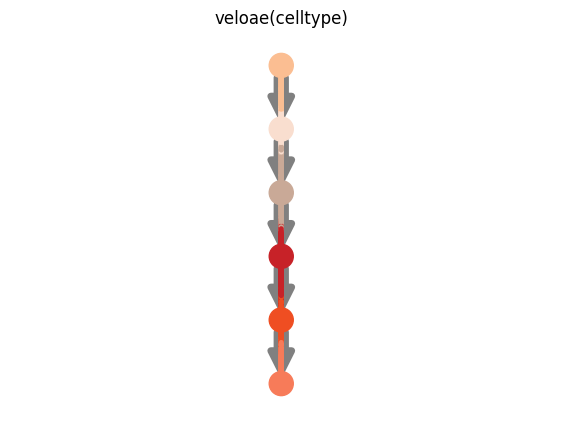

In [3]:
def get_filename(milestone_name):
    return f".cafe/gastrulation_{milestone_name.lower()}/h5ad/gastrulation_{milestone_name.lower()}.h5ad"


replace_milestone_dict = {
    "Blast":{
        # "fadata_sub_filename": ".cafe/gastrulation_blast/h5ad/gastrulation_blast.h5ad",
        "fadata_sub_filename": get_filename("Blast"),
        "sub_model_name": "ref" # mannual
    },
    "Ectoderm": {
        "fadata_sub_filename": get_filename("Ectoderm"),
        "sub_model_name": "ref"
    },
    "Mesoderm": {
        "fadata_sub_filename": get_filename("Mesoderm"),
        "sub_model_name": "ref"
    },
    "Endoderm": {
        "fadata_sub_filename": get_filename("Endoderm"),
        "sub_model_name": "ref"
    },
    "Neural": {
        "fadata_sub_filename": get_filename("Neural"),
        "sub_model_name": "ref"
    },
    "Blood": {
        "fadata_sub_filename": get_filename("Blood"),
        "sub_model_name": "veloae"  # veloae method result
    },
}
cluster_key = "celltype"
color_dict = dict(zip(fadata.obs[cluster_key].cat.categories, fadata.uns[f"{cluster_key}_colors"]))

# for visulization in paper, text should be added mannually
nx_draw_kwargs = {"with_labels": False}
# trajectory_sc_pl_embedding_kwargs = {"legend_loc": None}
graph_sc_pl_embedding_kwargs = {"size": 50, "legend_loc": None}

for replace_milestone, info in replace_milestone_dict.items():
    fadata_sub_filename = info["fadata_sub_filename"]
    sub_model_name = info["sub_model_name"]
    # load
    fadata_sub = cafe.data.read_h5ad(fadata_sub_filename)
    fadata_sub.load_trajectory_dict(sub_model_name)
    # set cell and milestone colors
    fadata_sub.uns[f"{cluster_key}_colors"] = [color_dict[i] for i in fadata_sub.obs[cluster_key].cat.categories]
    mw = fadata_sub.get_milestone_wrapper(sub_model_name)
    mw._milestone_color_dict = {i: color_dict[i] for i in mw.id_list}
    # plot
    try:
        cafe.plot.plot_trajectory(
            fadata_sub,
            model_name=sub_model_name,
            save=f"{img_dir}/plot_trajectory_{replace_milestone}.pdf",
            # **trajectory_sc_pl_embedding_kwargs
        )
        cafe.plot.plot_graph(
            fadata_sub,
            nx_draw_kwargs=nx_draw_kwargs,
            model_name=sub_model_name,
            save=f"{img_dir}/plot_graph_{replace_milestone}.pdf",
            **graph_sc_pl_embedding_kwargs
        )
    except Exception as e:
        cafe.logger.error(f"Error occurred while plotting for milestone: {replace_milestone}, Error: {e}")
    cafe.logger.info(f"Processed milestone: {replace_milestone}, fadata_sub shape: {fadata_sub.shape}, model_name: `{sub_model_name}`")